# This notebook analysis the output from `cheking_predictions_improved_cellmot_baseline`

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

file_path = Path('/kaggle/input/notebooks/sebastianvpal/checking-predictions-improved-cellmot-baseline/node_level_errors.parquet')
#opening file
df = pd.read_parquet(file_path)
#showing frist 5 elements
df.head(5)

,video_stem,t,z,y,x,detected,nn_dist_um,intensity_at_node,dist_to_edge_vox,local_contrast,n_neighbors_within_15um
0,6bba_372c8cb8,0,20.0,226.0,19.0,True,23.523945,0.041000,5,-0.207740,0
1,6bba_372c8cb8,0,26.0,236.0,190.0,True,28.051849,0.045867,26,0.028155,0
2,6bba_372c8cb8,0,29.0,182.0,8.0,True,23.523945,0.111600,2,0.362551,0
3,6bba_372c8cb8,0,41.0,56.0,35.0,True,38.800598,0.057129,9,-0.544675,0
4,6bba_372c8cb8,0,41.0,248.0,158.0,True,28.051849,0.317210,22,0.615929,0


In [2]:
len(df)

70887

In [3]:
print(df.groupby("video_stem")["t"].nunique())
print("="*15, " Not all videos have the same number of frames ", "="*15)

video_stem
44b6_0113de3b     52
44b6_0db75fae     89
44b6_12dfb391    100
44b6_1d530831    100
44b6_267148e4    100
                ... 
6bba_f1fde7e0     99
6bba_f8ffd5e7     93
6bba_fbc898dc    100
6bba_fc516dc6    100
6bba_fc83837d    100
Name: t, Length: 100, dtype: int64
===============  Not all videos have the same number of frames  ===============


In [4]:
print( "="*15, "Number of nodes for each file accros all frames ", "="*15)
print(df["video_stem"].value_counts())


=============== Number of nodes for each file accros all frames  ===============
video_stem
6bba_09961292    1950
6bba_bb9f20c3    1925
6bba_784a78c9    1788
6bba_ae82a791    1495
6bba_1d0d8384    1438
                 ... 
44b6_e31261b4     116
44b6_90724892     105
44b6_c15fded2     104
44b6_53f95252      70
44b6_0113de3b      52
Name: count, Length: 100, dtype: int64


In [5]:
pct_detected = (len(df[df["detected"]==True])/len(df))*100
pct_NO_detectec = (1-pct_detected/100)*100
print(f"Total number of GT cells: {len(df)}",
f"percentage of identified cells: {pct_detected}% ({len(df[df["detected"]==True])})",
      f"percentage of NO identified cells: {pct_NO_detectec}% ({len(df[df["detected"]==False])})",
f" In {len(df["video_stem"].unique())} videos")

Total number of GT cells: 70887 percentage of identified cells: 98.3791104151678% (69738) percentage of NO identified cells: 1.620889584832197% (1149)  In 100 videos


# Relationship between the number of no detected GT nodes and the number of total GT nodes


**Cecking if there is a relation between the number of no detected GT nodes and the number of total GT nodes**

It looks like there is no relationship between the number of nodes and how well the GT nodes are predicted


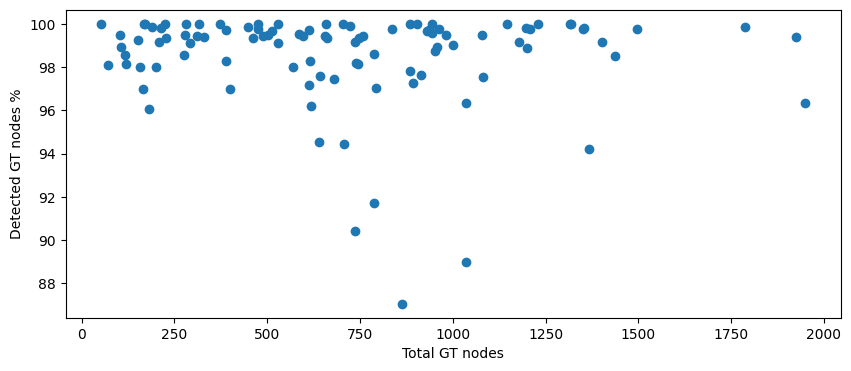

In [6]:
total_GT_nodes = df.groupby("video_stem")["video_stem"].count().sort_values()
detected_GT_nodes = df.groupby("video_stem")["detected"].sum().sort_values()
pct_detected_GT_nodes =( detected_GT_nodes/total_GT_nodes)*100


fig,ax = plt.subplots(figsize=(10,4))
ax.scatter(total_GT_nodes,pct_detected_GT_nodes)
ax.set_xlabel("Total GT nodes")
ax.set_ylabel("Detected GT nodes %")

print("="*100)
print("It looks like there is no relationship between the number of nodes and how well the GT nodes are predicted")
print("="*100)


 Total amount of predicted and not predicted GT nodes 


array([<Axes: title={'center': '(False, video_stem)'}, xlabel='detected'>,
       <Axes: title={'center': '(True, video_stem)'}, xlabel='detected'>],
      dtype=object)

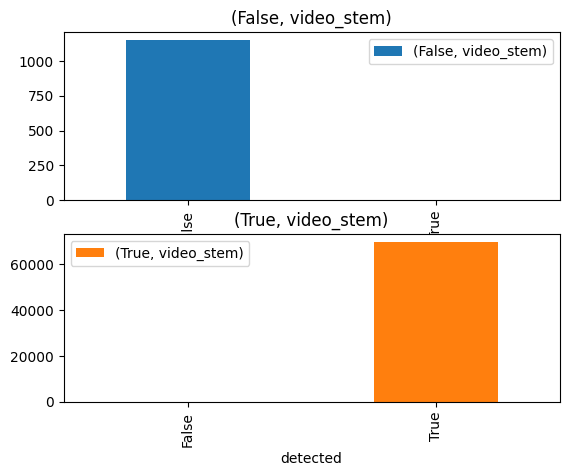

In [7]:
print("="*100)
print(" Total amount of predicted and not predicted GT nodes ")
print("="*100)

df.groupby("detected").count().plot.bar(column="video_stem", by = "detected")

# General statistics between predicted and not predicted GT nodes for different features

In [8]:
print("="*100)
print(" General statistics between predicted and not predicted GT nodes for different features ")
print("="*100)

 General statistics between predicted and not predicted GT nodes for different features 


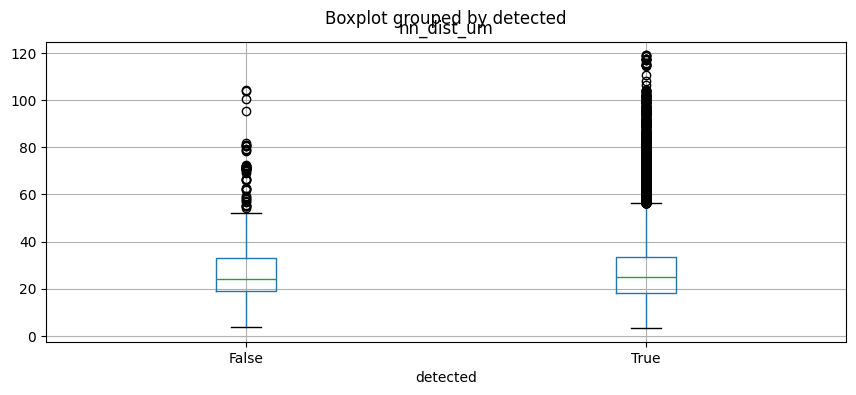

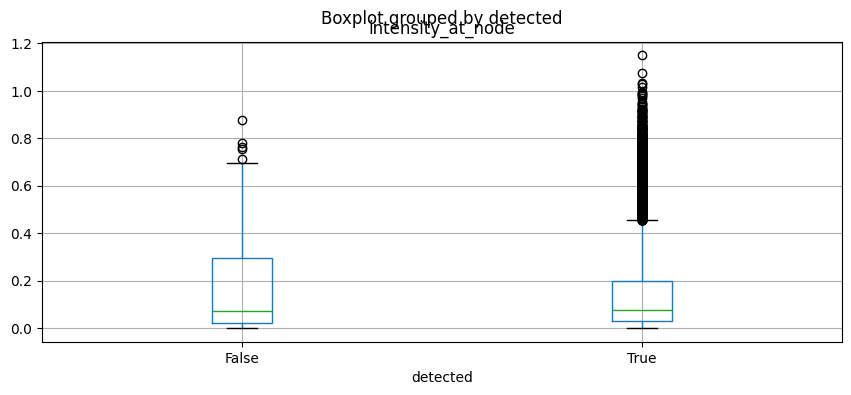

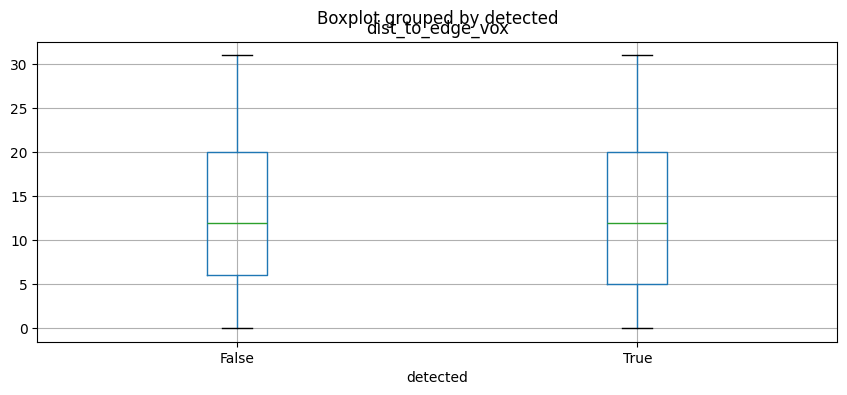

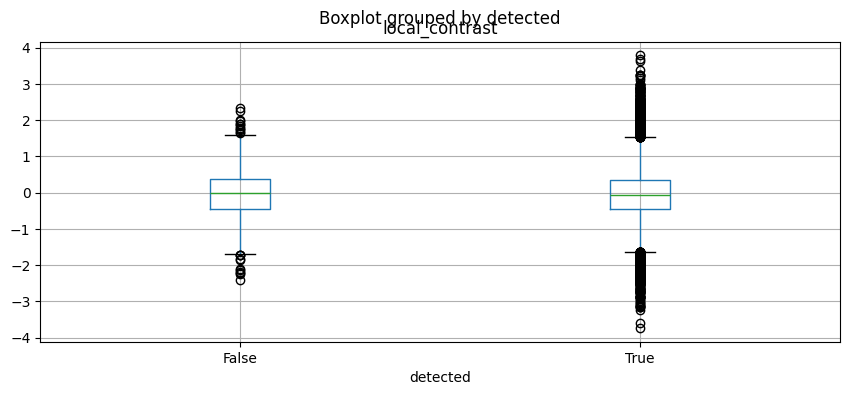

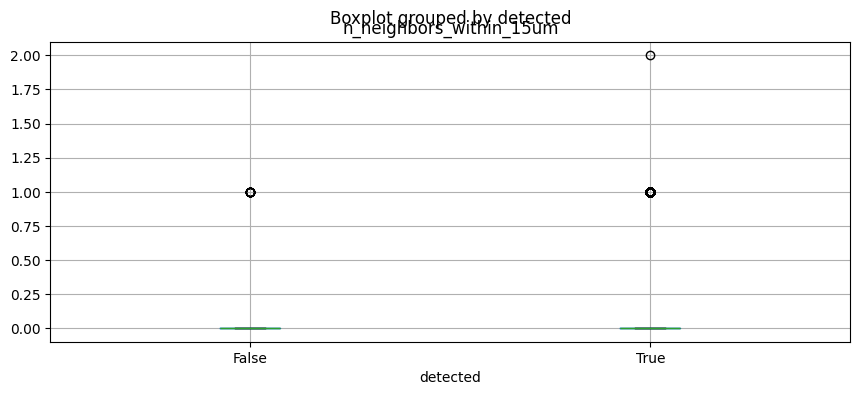

In [9]:
for col in df.columns[6:]:
    fig, ax = plt.subplots(1,1,figsize=(10,4))
    df.boxplot(column=col, by="detected",ax=ax)

In [10]:
print("="*100)
print(" It looks like correctly predicted nodes has longer tails in their distributions for"
     "some variables that are not present for the no predicted nodes")
print("="*100)

 It looks like correctly predicted nodes has longer tails in their distributions forsome variables that are not present for the no predicted nodes


# Video with the largest amount of no predicted GT nodes

In [11]:
print("="*100)
print(" Let's focus on the video with the largest amount of no predicted GT nodes ")
print("="*100)

 Let's focus on the video with the largest amount of no predicted GT nodes 


In [12]:
pct_detected_GT_nodes.sort_values()

video_stem
6bba_6feb10f0     87.061404
6bba_ab78413d     88.973707
6bba_474be664     90.410959
6bba_6479435d     91.734198
6bba_ebff6e76     94.233687
                    ...    
6bba_784a78c9    100.000000
6bba_d2b9fc0c    100.000000
6bba_d0fc38b5    100.000000
6bba_d5eae175    100.000000
6bba_b1ae37b9    100.000000
Length: 100, dtype: float64

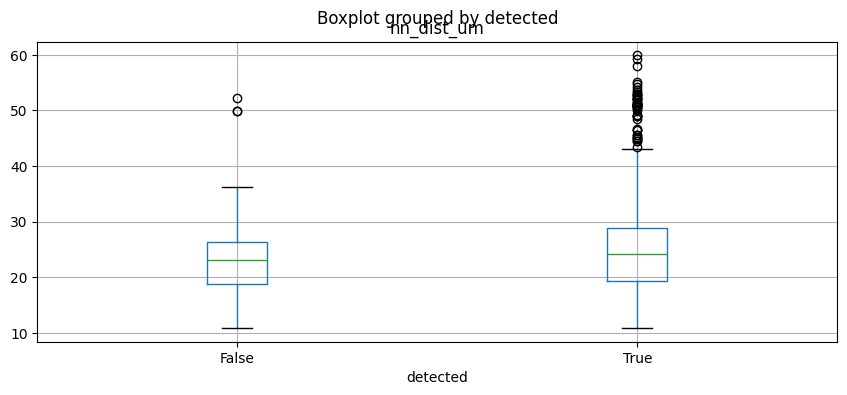

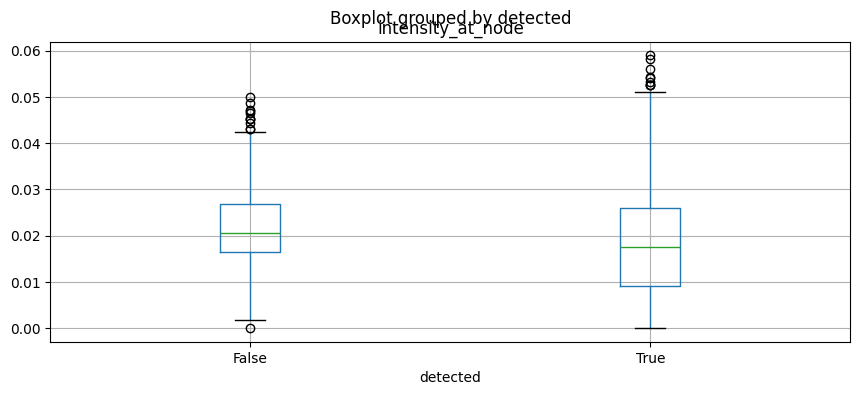

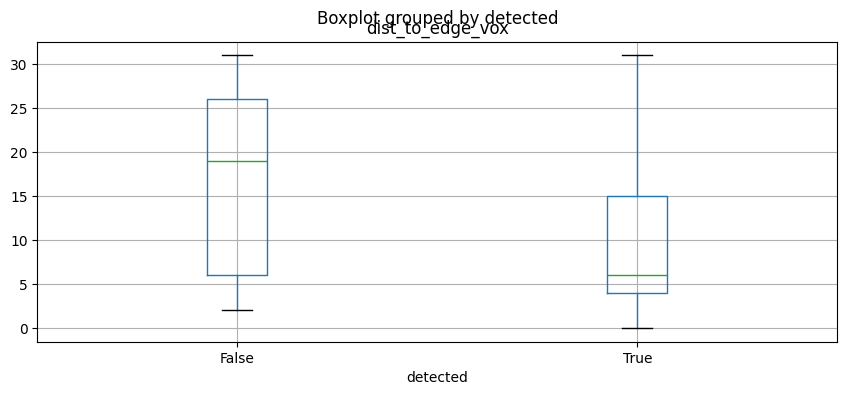

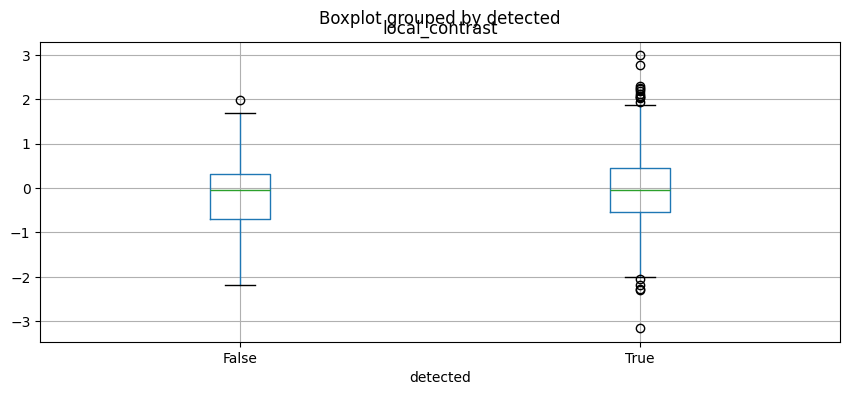

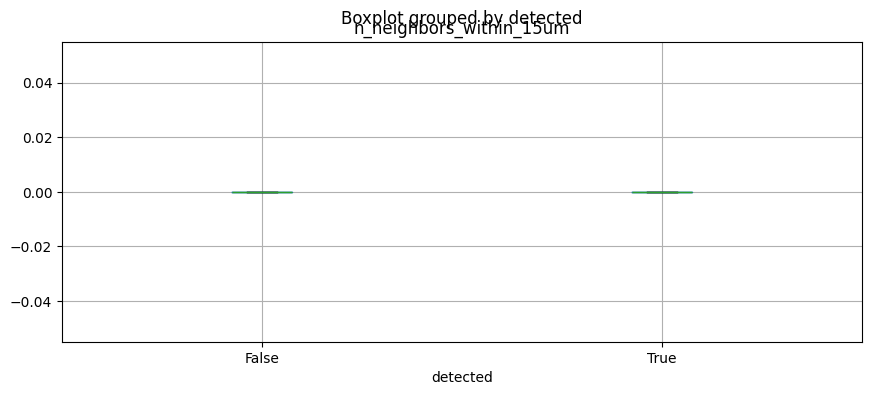

In [13]:
worst_video = "6bba_6feb10f0" #"6bba_6479435d"#"6bba_ab78413d"
best_video = "6bba_b1ae37b9"
df_wv = df[df["video_stem"] == worst_video] # Selecting the worst video
df_bv = df[df["video_stem"] == best_video] # Selecting the best video

for col in df_wv.columns[6:]:
    fig, ax = plt.subplots(1,1,figsize=(10,4))
    df_wv.boxplot(column=col, by="detected",ax=ax)


In [14]:
print("="*100)
print(" Let's see if there is something we can infer from the worst video at each time step ")
print("="*100)

 Let's see if there is something we can infer from the worst video at each time step 


 It looks like the worst video struggles to predict correctly de parent-child node relationship 
 The blue line (worst) presents a more oscillatory behavior while the best video (orange) shows
 a mor consitent behavior


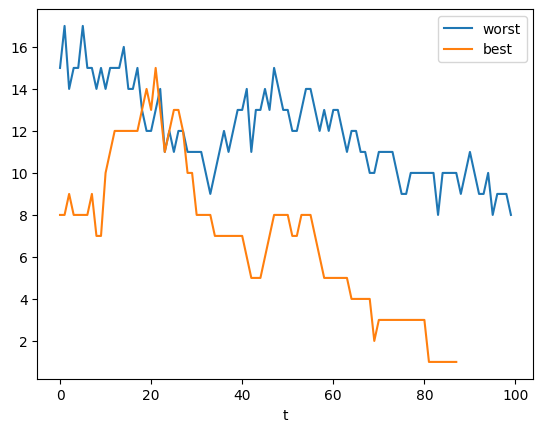

In [15]:
print("="*100)
print(" It looks like the worst video struggles to predict correctly de parent-child node relationship ")
print(" The blue line (worst) presents a more oscillatory behavior while the best video (orange) shows")
print(" a mor consitent behavior")
print("="*100)
df_wv.groupby("t")["detected"].sum().plot(label="worst")
df_bv.groupby("t")["detected"].sum().plot(label="best")
plt.legend()

In [16]:
print("="*100)
print(" Let's check further this idea plotting the firs worst and best videos ")
print("="*100)

 Let's check further this idea plotting the firs worst and best videos 


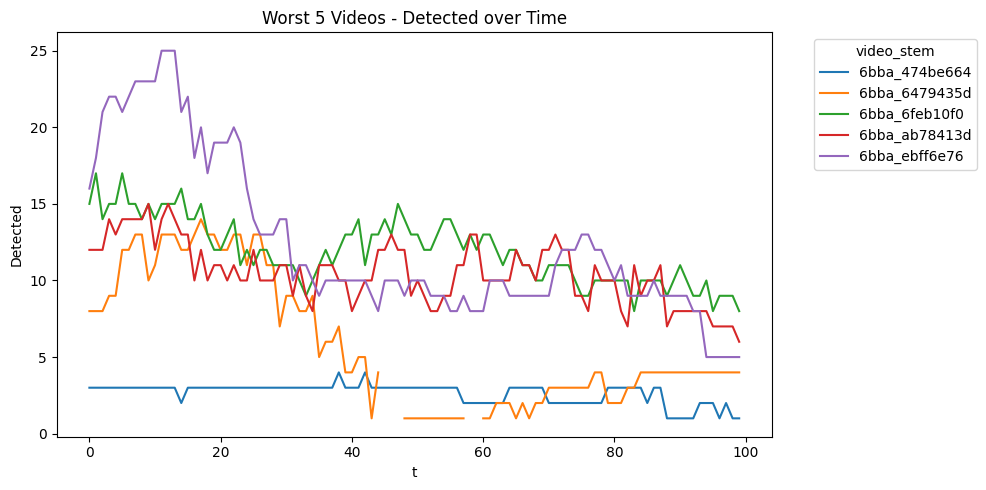

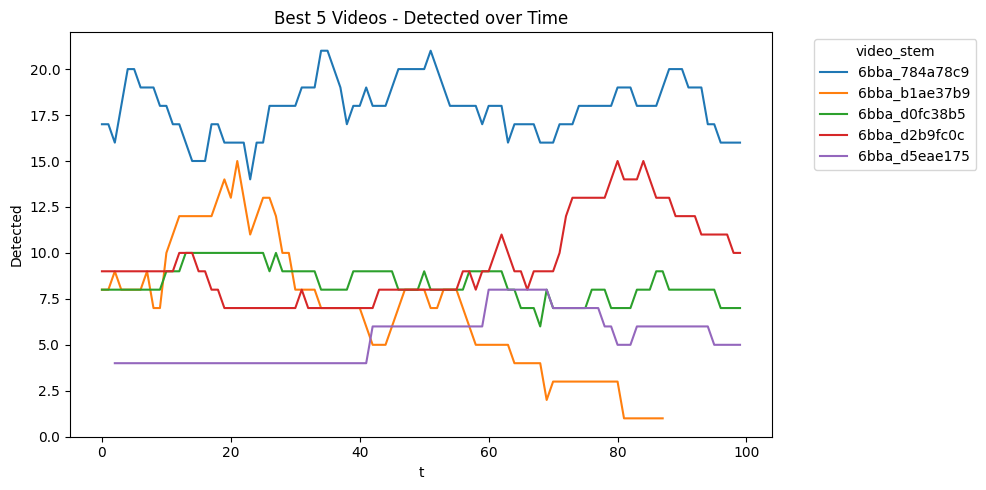

In [17]:
n = 5
worst_n_videos = pct_detected_GT_nodes.sort_values()[:n].index.values
best_n_videos = pct_detected_GT_nodes.sort_values()[-n:].index.values

df_wv_n = df[df["video_stem"].isin(worst_n_videos)] # Selecting the worst video
df_bv_n = df[df["video_stem"].isin(best_n_videos)] # Selecting the best video



# --- Worst N Videos Plot ---
plt.figure(figsize=(10, 5))
df_wv_n.groupby(["t", "video_stem"])["detected"].sum().unstack().plot(ax=plt.gca())
plt.title(f"Worst {n} Videos - Detected over Time")
plt.ylabel("Detected")
plt.legend(title="video_stem", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- Best N Videos Plot ---
plt.figure(figsize=(10, 5))
df_bv_n.groupby(["t", "video_stem"])["detected"].sum().unstack().plot(ax=plt.gca())
plt.title(f"Best {n} Videos - Detected over Time")
plt.ylabel("Detected")
plt.legend(title="video_stem", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Comparting worst/best predictions with GT annotations

In [18]:
print("="*100)
print(" Comparting worst/best predictions with GT annotations")
print("="*100)

 Comparting worst/best predictions with GT annotations


**Plotting predicted and GT amount of nodes at each time step**

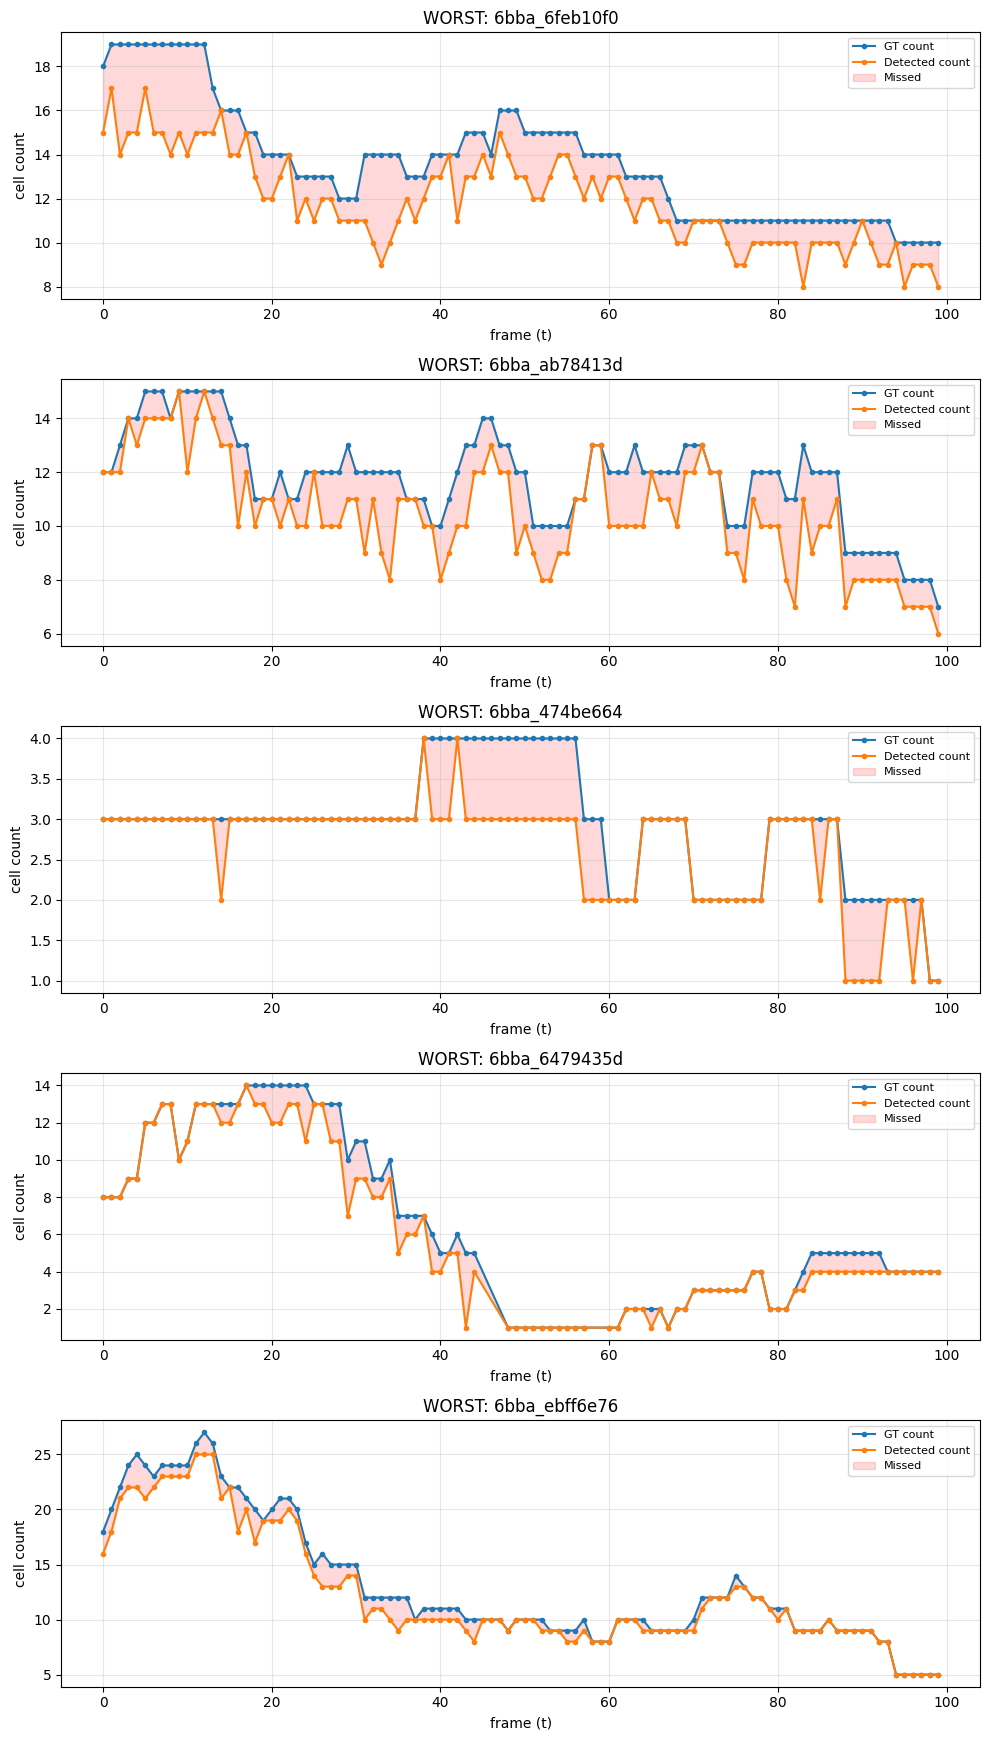

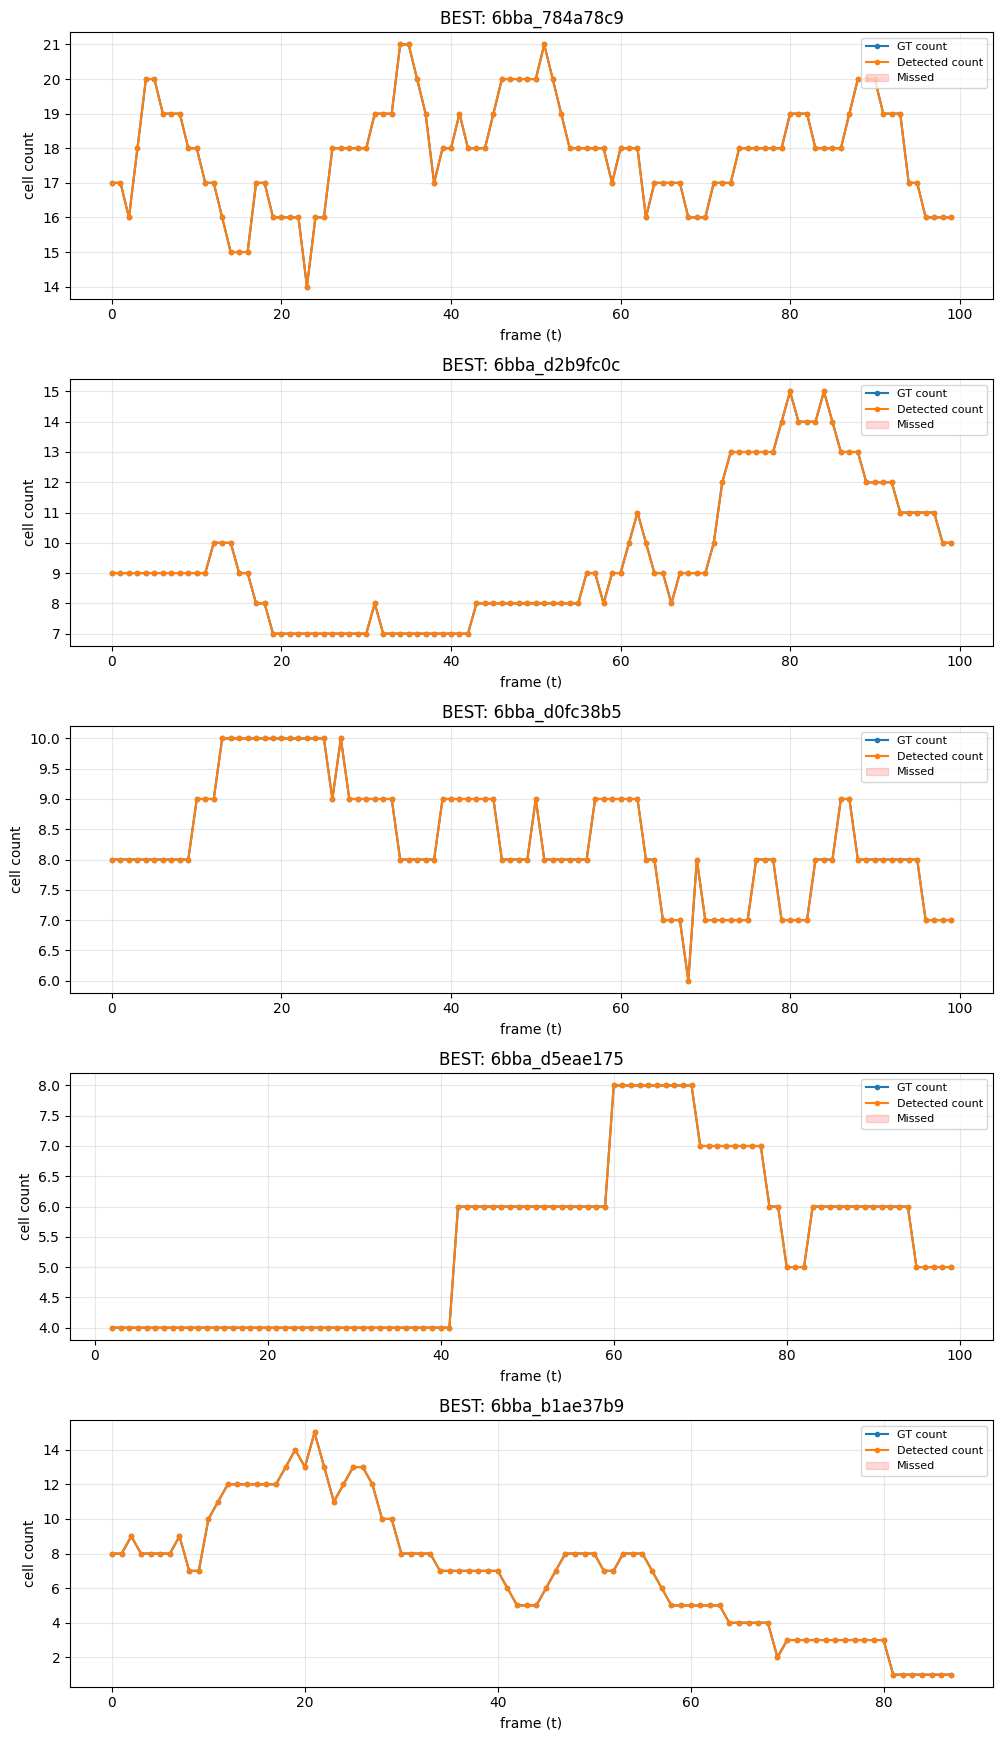

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gt_vs_detected(df_subset: pd.DataFrame, video_stems: list, title_prefix: str):
    fig, axes = plt.subplots(len(video_stems), 1, figsize=(10, 3.5 * len(video_stems)), sharex=False)
    if len(video_stems) == 1:
        axes = [axes]

    for ax, stem in zip(axes, video_stems):
        vid_df = df_subset[df_subset["video_stem"] == stem]

        per_frame = vid_df.groupby("t").agg(
            gt_count=("detected", "size"),        # total GT nodes that frame
            detected_count=("detected", "sum"),   # how many of them were matched
        ).sort_index()

        t = per_frame.index.values
        ax.plot(t, per_frame["gt_count"], marker="o", ms=3, label="GT count", color="tab:blue")
        ax.plot(t, per_frame["detected_count"], marker="o", ms=3, label="Detected count", color="tab:orange")
        ax.fill_between(t, per_frame["detected_count"], per_frame["gt_count"],
                         color="red", alpha=0.15, label="Missed")
        ax.set_title(f"{title_prefix}: {stem}")
        ax.set_xlabel("frame (t)")
        ax.set_ylabel("cell count")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_gt_vs_detected(df_wv_n, list(worst_n_videos), "WORST")
plot_gt_vs_detected(df_bv_n, list(best_n_videos), "BEST")

# Specific statistics to explore trends between the 2 groups: predicted/missed nodes

**The statistics are:**

- Levene: It is used to answer: does the spread between two distribution differ?
  
  _Observations:_ with a large number of samples N, even tiny variance differences become statistically significant. Additionally it assumess independence over observations. If **p value < 0.05** you reject the idea of equal variance (null hypothesis)

- Kolmogorov-Sminorv (KS) two-sample test: null hypothesis: both samples are drawn from the same distribution. The question it answers is are these the same distribution at all?

  _Observations:_ The statistic D is the maximum vertical gap between the two groups' empirical CDFs, at whatever point that gap is largest. **Cautions:** Extremely sensitive at large N. With enough data, KS will call almost any two real-world samples "significantly different" even when the practical difference is negligible

In [20]:
print("="*100)
print(" Let's explore one of the previous observations in which correctly predicted nodes"
     " have longer tails in their distributions than wrongly predicted nodes")
print("="*100)


 Let's explore one of the previous observations in which correctly predicted nodes have longer tails in their distributions than wrongly predicted nodes


In [21]:
from scipy import stats
metrics = ["nn_dist_um", "intensity_at_node","local_contrast","dist_to_edge_vox"]
detected_contrast = df.loc[df["detected"], "local_contrast"].dropna()
missed_contrast = df.loc[~df["detected"], "local_contrast"].dropna()

dfs = []
levene_ = []
KS_ = []
for metric in metrics:
    detected_metric = df.loc[df["detected"], metric].dropna()
    missed_metric = df.loc[~df["detected"], metric].dropna()
    print("="*100)
    print("="*30, f" Metric: {metric} ", "="*30)
    # tests sensitive to variance/spread differences, not just median shift:
    stats_le, p_le = stats.levene(detected_metric, missed_metric)
    print("Levene (variance):", stats_le, p_le)
    print("="*30)
    # print("Brown-Forsythe:", stats.levene(detected_metric, missed_metric, center="median"))  # more robust to non-normality
    # print("="*30)
    stats_ks, p_ks = stats.ks_2samp(detected_metric, missed_metric)
    print("KS test (full distribution shape):", stats_ks, p_ks)
    print("="*30)
    # quantify tail weight directly:
    for q in [0.01, 0.05, 0.95, 0.99]:
        print(f"q={q}: detected={detected_metric.quantile(q):.3f}, missed={missed_metric.quantile(q):.3f}")
    print("\n")
    ##
    levene_ = [stats_le, p_le] #.append([stats_le, p_le])
    KS_ = [stats_ks, p_ks] #.append([stats_ks, p_ks])
    temp_df = pd.DataFrame(
        [levene_, KS_],
        columns=["statistics_" + metric, "p_value_" + metric],
        index=["Levene", "KS"]
    )
    dfs.append(temp_df)

# Combine all mini-DataFrames horizontally into one final DataFrame
df_stats = pd.concat(dfs, axis=1)

==============================  Metric: nn_dist_um  ==============================
Levene (variance): 0.17675904303669182 0.6741746754313409
KS test (full distribution shape): 0.04896334748445627 0.008905323415880267
q=0.01: detected=7.324, missed=7.044
q=0.05: detected=11.605, missed=11.830
q=0.95: detected=50.924, missed=51.621
q=0.99: detected=67.844, missed=76.149


==============================  Metric: intensity_at_node  ==============================
Levene (variance): 69.70113380212747 7.023248249758334e-17
KS test (full distribution shape): 0.10630014151437528 1.4242442607143413e-11
q=0.01: detected=0.003, missed=0.002
q=0.05: detected=0.009, missed=0.007
q=0.95: detected=0.457, missed=0.525
q=0.99: detected=0.646, missed=0.650


==============================  Metric: local_contrast  ==============================
Levene (variance): 0.9109497939303924 0.3398657906839876
KS test (full distribution shape): 0.05463200683917502 0.002261379592621533
q=0.01: detected=-1.691, misse

In [22]:
print(df_stats)

        statistics_nn_dist_um  p_value_nn_dist_um  \
Levene               0.176759            0.674175   
KS                   0.048963            0.008905   

        statistics_intensity_at_node  p_value_intensity_at_node  \
Levene                     69.701134               7.023248e-17   
KS                          0.106300               1.424244e-11   

        statistics_local_contrast  p_value_local_contrast  \
Levene                   0.910950                0.339866   
KS                       0.054632                0.002261   

        statistics_dist_to_edge_vox  p_value_dist_to_edge_vox  
Levene                     0.025454                  0.873241  
KS                         0.036955                  0.089068  


#### Visual exploration of the CDF

detected: n=69161, min=3.300, max=118.928
missed:   n=1141, min=3.723, max=104.406


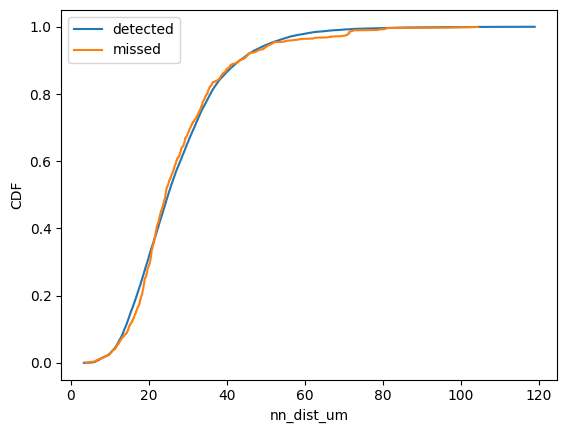

detected: n=69738, min=0.000, max=1.149
missed:   n=1149, min=0.000, max=0.878


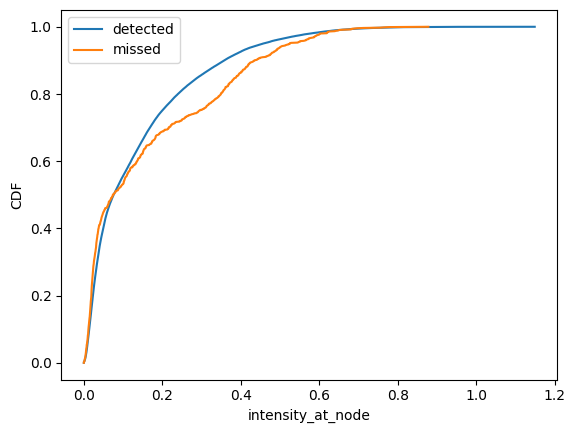

detected: n=69738, min=-3.736, max=3.787
missed:   n=1149, min=-2.410, max=2.331


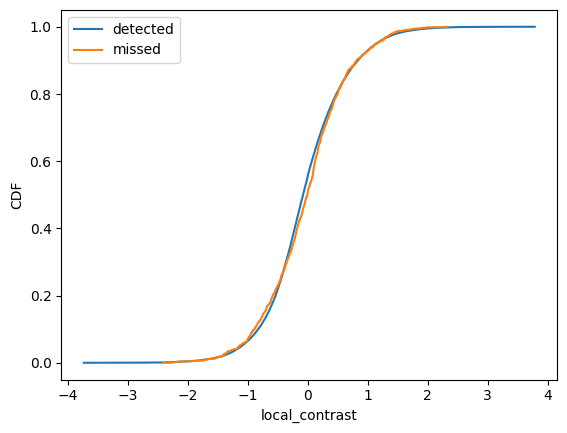

detected: n=69738, min=0.000, max=31.000
missed:   n=1149, min=0.000, max=31.000


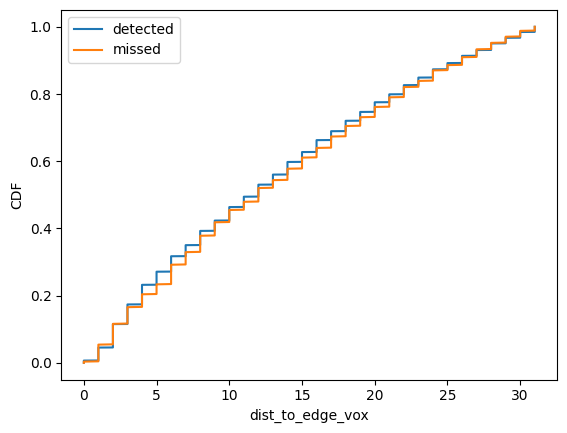

In [23]:
# metric = "intensity_at_node"
for metric in metrics:
    detected_nn = df.loc[df["detected"], metric].dropna()
    missed_nn = df.loc[~df["detected"], metric].dropna()
    
    print(f"detected: n={len(detected_nn)}, min={detected_nn.min():.3f}, max={detected_nn.max():.3f}")
    print(f"missed:   n={len(missed_nn)}, min={missed_nn.min():.3f}, max={missed_nn.max():.3f}")
    
    # check exactly where the KS statistic's max-gap point falls, and what's around it
    import numpy as np
    sorted_d = np.sort(detected_nn.values)
    sorted_m = np.sort(missed_nn.values)
    # plot both empirical CDFs directly — this will visually show you the pathology
    import matplotlib.pyplot as plt
    plt.plot(sorted_d, np.linspace(0, 1, len(sorted_d)), label="detected")
    plt.plot(sorted_m, np.linspace(0, 1, len(sorted_m)), label="missed")
    plt.legend(); plt.xlabel(metric); plt.ylabel("CDF")
    plt.show()

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

features = ["nn_dist_um", "intensity_at_node", "local_contrast","dist_to_edge_vox"]  # extend as you add more

model_diag = df.dropna(subset=features + ["detected"])
X = model_diag[features].values
X_scaled = StandardScaler().fit_transform(X)
y = model_diag["detected"].values.astype(int) #from boolean to int

# clf = LogisticRegression(class_weight="balanced").fit(X, y)
clf = LogisticRegression(class_weight="balanced").fit(X_scaled, y)
auc = roc_auc_score(y, clf.predict_proba(X_scaled)[:, 1])
print(f"AUC: {auc:.3f}")   # 0.5 = no predictive power, 1.0 = perfect separation
print("="*30)
print(dict(zip(features, clf.coef_[0])))

AUC: 0.531
{'nn_dist_um': np.float64(-0.03627603619327418), 'intensity_at_node': np.float64(-0.13921470646172215), 'local_contrast': np.float64(0.013920180854022461), 'dist_to_edge_vox': np.float64(-0.05841766009549347)}


##### AUC of ~ 0.5 is equivalent to random guessing, it means that a linear model composed of the selected features can not predict if a voxel is a cell or not

# Conclusions

#### So far, this study has shown:


##### Among the studied variables, `intensity_at_node` shows to be the only one presenting a clear difference between detected and missed nodes. Missed nodes (in average) presented larger extremes in intensity than detected ones, i.e, missed nodes has the lowest/highest intensity than detected nodes. This conclusion is based on the statistical and visual analysis. 

##### Training the baseline model further probably won't bring much improvement as it has already been trained with all the available data.


#### Our efforts should now focus on: 

##### - implementing/improving a new model that has similar properties as the baseline model but  improves over its weakness: voxels with low intensity. 

##### - Explore to expand the attention to more than 2 frames. This is motivated by the plots of the worst predictions where cells seem to disappear and emerge spontaneously, if larger attention is give, the model will penalized stronger cells that has no temporal connection.